In [ ]:
import os

os.environ['KAGGLE_USERNAME'] = "thihah"
os.environ['KAGGLE_KEY'] = "KGAT_61b7690d8541f2c10e8d7a982a90396a"

!pip install -q kaggle

!kaggle datasets download -d jiayuanchengala/aid-scene-classification-datasets

!unzip -q aid-scene-classification-datasets.zip -d ./AID_Dataset

Dataset URL: https://www.kaggle.com/datasets/jiayuanchengala/aid-scene-classification-datasets
License(s): CC0-1.0
100% 2.45G/2.45G [00:21<00:00, 125MB/s]



In [ ]:
data_path = './AID_Dataset/AID'
classes = sorted(os.listdir(data_path))

print(f"{'Class Name':<25} | {'Image Count':<10}")
print("-" * 40)

for cls in classes:
    count = len(os.listdir(os.path.join(data_path, cls)))
    print(f"{cls:<25} | {count:<10}")

print("-" * 40)
print(f"Total Classes: {len(classes)}")

Class Name                | Image Count
----------------------------------------
Airport                   | 360       
BareLand                  | 310       
BaseballField             | 220       
Beach                     | 400       
Bridge                    | 360       
Center                    | 260       
Church                    | 240       
Commercial                | 350       
DenseResidential          | 410       
Desert                    | 300       
Farmland                  | 370       
Forest                    | 250       
Industrial                | 390       
Meadow                    | 280       
MediumResidential         | 290       
Mountain                  | 340       
Park                      | 350       
Parking                   | 390       
Playground                | 370       
Pond                      | 420       
Port                      | 380       
RailwayStation            | 260       
Resort                    | 290       
River                 

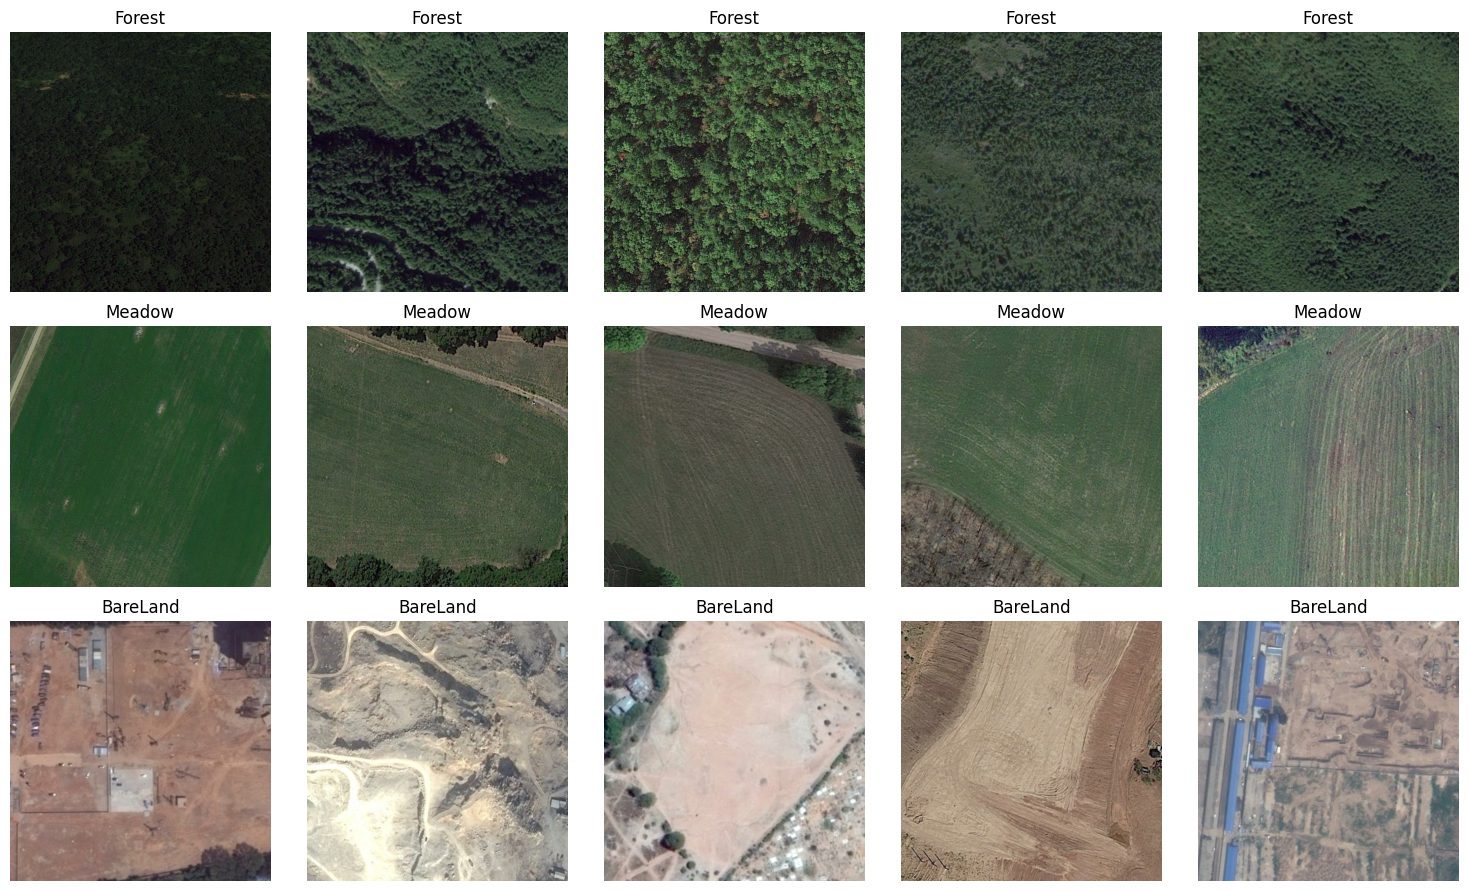

In [ ]:
import matplotlib.pyplot as plt
import PIL.Image as Image
import random

def plot_random_samples(base_path, num_classes=3, imgs_per_class=5):
    classes = random.sample(os.listdir(base_path), num_classes)
    plt.figure(figsize=(15, 3 * num_classes))

    for i, cls in enumerate(classes):
        cls_path = os.path.join(base_path, cls)
        img_names = random.sample(os.listdir(cls_path), imgs_per_class)

        for j, img_name in enumerate(img_names):
            plt.subplot(num_classes, imgs_per_class, i * imgs_per_class + j + 1)
            img = Image.open(os.path.join(cls_path, img_name))
            plt.imshow(img)
            plt.title(f"{cls}")
            plt.axis('off')
    plt.tight_layout()
    plt.show()

plot_random_samples(data_path)

In [ ]:
import cv2

sample_img_path = os.path.join(data_path, 'Airport', 'airport_1.jpg')
img = cv2.imread(sample_img_path)

print(f"Kích thước (H, W, C): {img.shape}")
print(f"Kiểu dữ liệu: {img.dtype}")
print(f"Giá trị Pixel lớn nhất: {img.max()}")
print(f"Giá trị Pixel nhỏ nhất: {img.min()}")

Kích thước (H, W, C): (600, 600, 3)
Kiểu dữ liệu: uint8
Giá trị Pixel lớn nhất: 255
Giá trị Pixel nhỏ nhất: 0


/tmp/ipykernel_4156/3590757053.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Count', y='Class', data=df, palette='viridis')


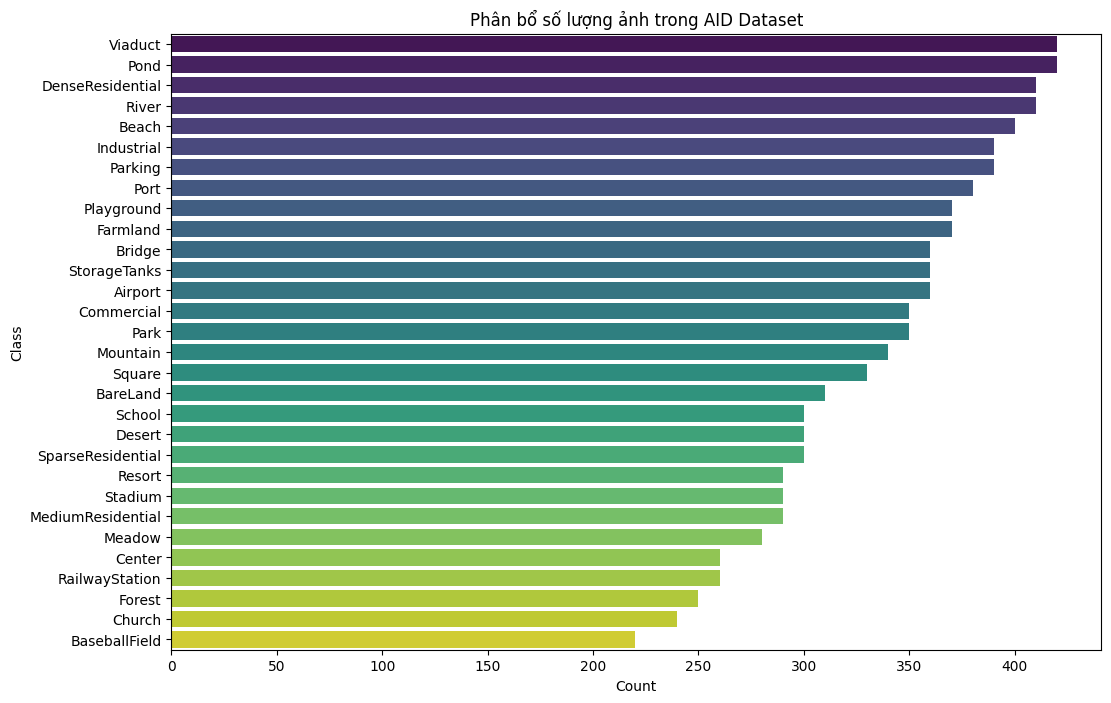

In [ ]:
import pandas as pd
import seaborn as sns

counts = {cls: len(os.listdir(os.path.join(data_path, cls))) for cls in classes}
df = pd.DataFrame(list(counts.items()), columns=['Class', 'Count']).sort_values('Count', ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(x='Count', y='Class', data=df, palette='viridis')
plt.title('Phân bổ số lượng ảnh trong AID Dataset')
plt.show()

In [ ]:
!pip install -q split-folders

import splitfolders

input_folder = "./AID_Dataset/AID"     # Thư mục AID gốc hiện tại
output_folder = "./AID_Dataset_Split"  # Thư mục mới sau khi chia

splitfolders.ratio(
    input_folder,
    output=output_folder,
    seed=42,
    ratio=(0.7, 0.15, 0.15),
    group_prefix=None
)

Copying files: 10000 files [00:13, 721.71 files/s]


In [ ]:
import os
import torch
from torchvision import transforms, datasets
from torch.utils.data import DataLoader

data_transforms = {
    'train': transforms.Compose([
        transforms.Resize(256),
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.RandomVerticalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'test': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

base_dir = './AID_Dataset_Split'

# Nạp ImageFolder cho cả 3 tập
image_datasets = {
    x: datasets.ImageFolder(os.path.join(base_dir, x), transform=data_transforms[x])
    for x in ['train', 'val', 'test']
}

dataloaders = {
    x: DataLoader(
        image_datasets[x],
        batch_size=32,
        shuffle=(x == 'train'),
        num_workers=2
    )
    for x in ['train', 'val', 'test']
}

dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'val', 'test']}
class_names = image_datasets['train'].classes

print(f"Số lượng ảnh: {dataset_sizes}")
print(f"Số lượng classes: {len(class_names)}")

Số lượng ảnh: {'train': 6993, 'val': 1493, 'test': 1514}
Số lượng classes: 30


In [ ]:
import torch
import torch.nn as nn
from torchvision import models

# 1. Cấu hình thiết bị (Ưu tiên dùng GPU nếu có)
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Đang sử dụng thiết bị: {device}")

# 2. Tải pre-trained model ResNet-50
# Sử dụng weights mới nhất của ImageNet để mô hình có "mắt nhìn" tốt nhất
model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)

# [Tùy chọn]: Đóng băng (Freeze) các lớp Convolutional ban đầu.
# Nếu máy bạn yếu hoặc muốn train nhanh, hãy bỏ comment 2 dòng dưới đây để chỉ train lớp cuối.
# for param in model.parameters():
#     param.requires_grad = False

# 3. Thay thế lớp phân loại (Fully Connected - FC) ở cuối cùng
# ResNet50 gốc1000 classes, chúng ta cần đổi nó thành 30 classes cho tập AID xuất ra
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 30) # 30 là số lượng classes của AID

# Chuyển mô hình vào GPU/CPU
model = model.to(device)

# 4. Khai báo Hàm mất mát (Loss) và Thuật toán tối ưu (Optimizer)
# CrossEntropyLoss rất phù hợp cho bài toán phân loại nhiều lớp
criterion = nn.CrossEntropyLoss()

# Dùng Adam optimizer với Learning Rate nhỏ (0.0001) vì chúng ta đang fine-tune
# Nếu train từ đầu, LR thường lớn hơn (ví dụ 0.001)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

# 5. [Khuyên dùng] Tự động giảm Learning Rate nếu validation loss không giảm
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=3, factor=0.1)

print("Khởi tạo thành công kiến trúc ResNet-50 cho AID Dataset!")

Đang sử dụng thiết bị: cuda:0
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 124MB/s]


Khởi tạo thành công kiến trúc ResNet-50 cho AID Dataset!


In [ ]:
import time
import copy
import torch

def train_model(model, criterion, optimizer, scheduler, num_epochs=15):
    since = time.time() # Bắt đầu bấm giờ

    # Biến để lưu trữ model tốt nhất
    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0

    for epoch in range(num_epochs):
        print(f'Epoch {epoch+1}/{num_epochs}')
        print('-' * 10)

        # Mỗi epoch có 2 pha: Huấn luyện (train) và Đánh giá (val)
        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()  # Đặt mô hình ở chế độ huấn luyện (bật Dropout, BatchNorm...)
            else:
                model.eval()   # Đặt mô hình ở chế độ đánh giá (tắt Dropout...)

            running_loss = 0.0
            running_corrects = 0

            # Lặp qua từng batch dữ liệu
            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device)

                # Reset gradient về 0 sau mỗi bước
                optimizer.zero_grad()

                # Feed forward (Truyền xuôi)
                # Chỉ tính toán gradient nếu đang ở pha 'train'
                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    # Backpropagation (Lan truyền ngược) và tối ưu hóa
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                # Cộng dồn loss và số dự đoán đúng
                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            # Cập nhật Learning Rate (nếu dùng scheduler)
            if phase == 'train' and scheduler is not None:
                # Lưu ý: ReduceLROnPlateau cần truyền val_loss vào, nên ta sẽ gọi nó ở cuối pha val
                pass

            # Tính Loss và Accuracy trung bình của cả epoch
            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects.double() / dataset_sizes[phase]

            print(f'{phase.capitalize()} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

            # Cập nhật Scheduler dựa trên Validation Loss
            if phase == 'val' and scheduler is not None:
                scheduler.step(epoch_loss)

            # Nếu đây là kết quả tốt nhất trên tập Val, ta lưu lại!
            if phase == 'val' and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())

                # Lưu file thẳng ra ổ cứng để dự phòng
                torch.save(model.state_dict(), 'best_aid_resnet50.pth')
                print(" => Đã lưu mô hình tốt nhất (Accuracy tăng)!")

        print()

    time_elapsed = time.time() - since
    print(f'Huấn luyện hoàn tất trong {time_elapsed // 60:.0f} phút {time_elapsed % 60:.0f} giây')
    print(f'Độ chính xác cao nhất trên tập Val: {best_acc:4f}')

    # Nạp lại trọng số tốt nhất vào mô hình trước khi trả về
    model.load_state_dict(best_model_wts)
    return model

# BẮT ĐẦU HUẤN LUYỆN!
# Bạn có thể đổi num_epochs lên 20 hoặc 30 tùy vào thời gian bạn có
model = train_model(model, criterion, optimizer, scheduler, num_epochs=15)

Epoch 1/15
----------
Train Loss: 1.4729 Acc: 0.6428
Val Loss: 0.3611 Acc: 0.8888
 => Đã lưu mô hình tốt nhất (Accuracy tăng)!

Epoch 2/15
----------
Train Loss: 0.4635 Acc: 0.8654
Val Loss: 0.2331 Acc: 0.9297
 => Đã lưu mô hình tốt nhất (Accuracy tăng)!

Epoch 3/15
----------
Train Loss: 0.3448 Acc: 0.8978
Val Loss: 0.1944 Acc: 0.9404
 => Đã lưu mô hình tốt nhất (Accuracy tăng)!

Epoch 4/15
----------
Train Loss: 0.2773 Acc: 0.9224
Val Loss: 0.1628 Acc: 0.9471
 => Đã lưu mô hình tốt nhất (Accuracy tăng)!

Epoch 5/15
----------
Train Loss: 0.2370 Acc: 0.9294
Val Loss: 0.1741 Acc: 0.9444

Epoch 6/15
----------
Train Loss: 0.2096 Acc: 0.9361
Val Loss: 0.1668 Acc: 0.9464

Epoch 7/15
----------
Train Loss: 0.2030 Acc: 0.9372
Val Loss: 0.1417 Acc: 0.9591
 => Đã lưu mô hình tốt nhất (Accuracy tăng)!

Epoch 8/15
----------
Train Loss: 0.1916 Acc: 0.9435
Val Loss: 0.1515 Acc: 0.9551

Epoch 9/15
----------
Train Loss: 0.1670 Acc: 0.9489
Val Loss: 0.1436 Acc: 0.9591

Epoch 10/15
----------
Train

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# 1. Đảm bảo model đang ở chế độ đánh giá (tắt Dropout, BatchNorm)
model.eval()

all_preds = []
all_labels = []

print("Đang tiến hành kiểm thử trên tập Test...")

# 2. Tắt tính toán gradient để tiết kiệm bộ nhớ và tăng tốc quá trình suy luận (inference)
with torch.no_grad():
    for inputs, labels in dataloaders['test']:
        inputs = inputs.to(device)
        labels = labels.to(device)

        # Dự đoán
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)

        # Lưu lại kết quả để vẽ biểu đồ
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# 3. Tính toán độ chính xác tổng thể (Overall Accuracy)
corrects = np.sum(np.array(all_preds) == np.array(all_labels))
test_acc = corrects / len(all_labels)
print(f"Độ chính xác tổng thể trên tập Test: {test_acc * 100:.2f}%\n")

# 4. Vẽ Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(16, 14))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Dự đoán của Mô hình (Predicted)')
plt.ylabel('Thực tế (True Label)')
plt.title('Ma trận nhầm lẫn (Confusion Matrix) trên tập Test - AID')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

print("\nBáo cáo phân loại chi tiết (Classification Report):")
print(classification_report(all_labels, all_preds, target_names=class_names))

Đang tiến hành kiểm thử trên tập Test...
